In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

from scipy.optimize import curve_fit

In [3]:
def NORM(X):
    X = np.matrix(X)
    return np.sqrt(np.trace(X.H@X))

def OP_NORM(X):
    X = np.matrix(X)
    v = np.linalg.eigvals(X.H@X)
    return np.real(np.sqrt(np.max(v)))
    

# Model definition

#### Parameters

In [4]:
n = 20
m = 5

L_norm = .5 

N = 20

dt = 0.02
Nt = 500

In [5]:
L = np.random.rand(n*n).reshape([n,n])
v = np.linalg.eigvals(L)
M = np.max(np.abs(v))
L = L - np.eye(n)*M
L = L/OP_NORM(L)*L_norm

R = np.zeros([m,n])
R[:m,:m] = np.eye(m)
J = np.zeros([n,m])
J[:m,:m] = np.eye(m)

In [6]:
ts = np.arange(Nt+1)*dt

## Simulation of the original model

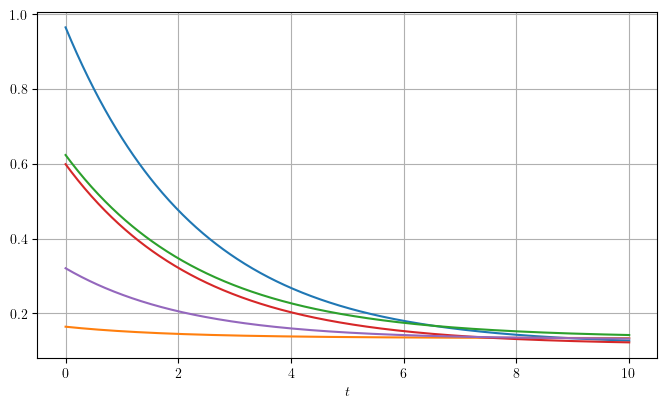

In [7]:
x_0 = J@R@np.random.rand(n)
 
A = sp.linalg.expm(L*dt)

x_t = x_0

ys = [R@x_t]
for j in range(Nt):
    x_t = A@x_t
    ys.append(R@x_t)

ys = np.array(ys).reshape([len(ts),m])

plt.figure(figsize=(16/2,9/2))
plt.plot(ts,ys)
plt.grid()
plt.xlabel(r'$t$')
plt.show()

# Approximation

In [8]:
def get_Fs(L,J,R,order):
    Fs = [np.zeros([m,m])]

    for k in range(1,order+1):
        F = R@np.linalg.matrix_power(L,k)@J /math.factorial(k-1)
        C = np.zeros_like(F)
        for h in range(1,k):
            C += Fs[k-h]@R@np.linalg.matrix_power(L,h)@J /math.factorial(h)
        Fs.append(F - C)
    return Fs

def get_Es(Fs, M_max=50):
    Es = [np.eye(m)]
    for k in range(1,M_max):
        E = np.zeros([m,m], dtype=np.float64)
        for s in range(1,k+1):
            if s< len(Fs):
                E = E + Fs[s]@Es[k-s]/k
        Es.append(E)
    return Es

Fs = get_Fs(L,J,R,N)
Es = get_Es(Fs, M_max=60)

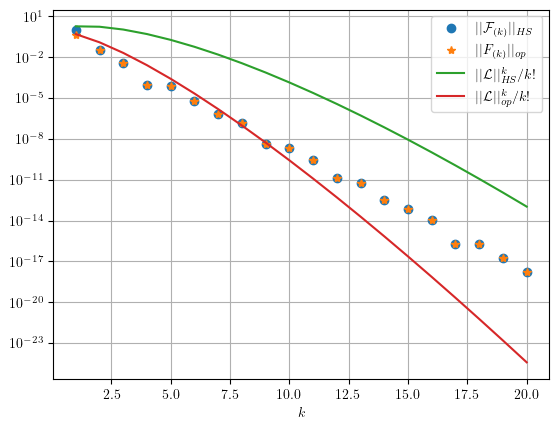

In [9]:
ks = np.arange(len(Fs))

norms_F = []
op_norms_F = []
for F in Fs:
    norms_F.append(NORM(F))
    op_norms_F.append(OP_NORM(F))

theoretical = [0]
op_theoretical = [0]
for k in ks[1:]:
    theoretical.append(NORM(L)**k/math.factorial(k))
    op_theoretical.append(OP_NORM(L)**k/math.factorial(k))

plt.figure()
plt.plot(ks[1:],norms_F[1:],'o',label=r'$||\mathcal{F}_{(k)}||_{HS}$')
plt.plot(ks[1:],op_norms_F[1:],'*',label=r'$||F_{(k)}||_{op}$')
plt.plot(ks[1:],theoretical[1:],label=r'$||\mathcal{L}||_{HS}^k/k!$')
plt.plot(ks[1:],op_theoretical[1:],label=r'$||\mathcal{L}||_{op}^k/k!$')
plt.yscale('log')
plt.grid()
plt.legend()
plt.xlabel(r'$k$')
plt.show()


df=pd.DataFrame(np.array([ks[1:],norms_F[1:],op_norms_F[1:],theoretical[1:],op_theoretical[1:]]).T, columns=['k','n','o','b','s'])
df.to_csv('../data/norm.csv', index=False)

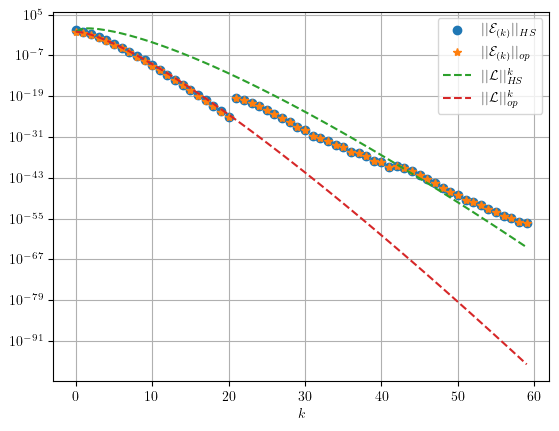

In [10]:
ks = np.arange(0,len(Es))
norms_E = []
op_norms_E = []
for E in Es:
    norms_E.append(NORM(E))
    op_norms_E.append(OP_NORM(E))

E_bound = []
op_E_bound = []
for k in ks:
    if k==0:
        E_bound.append(1)
        op_E_bound.append(1)
    else:
        b = NORM(R)*NORM(J)*NORM(L)**(k)/math.factorial(k)
        E_bound.append(b)
        b = OP_NORM(L)**(k)/math.factorial(k)
        op_E_bound.append(b)

plt.figure()
plt.plot(ks,norms_E,'o',label=r'$||\mathcal{E}_{(k)}||_{HS}$')
plt.plot(ks,op_norms_E,'*',label=r'$||\mathcal{E}_{(k)}||_{op}$')
plt.plot(ks,E_bound,'--',label=r'$||\mathcal{L}||_{HS}^k$')
plt.plot(ks,op_E_bound,'--',label=r'$||\mathcal{L}||_{op}^k$')
plt.yscale('log')
plt.xlabel(r'$k$')
plt.grid()
#plt.xlim([0,20])
#plt.ylim([10e-12,1])
plt.legend()
plt.show()


df=pd.DataFrame(np.array([ks,norms_E,op_norms_E,E_bound,op_E_bound]).T, columns=['k','n','o','b','s'])
df.to_csv('../data/E_norm.csv', index=False)

### Simulation of the second order approximation using Runge-Kutta 5 method

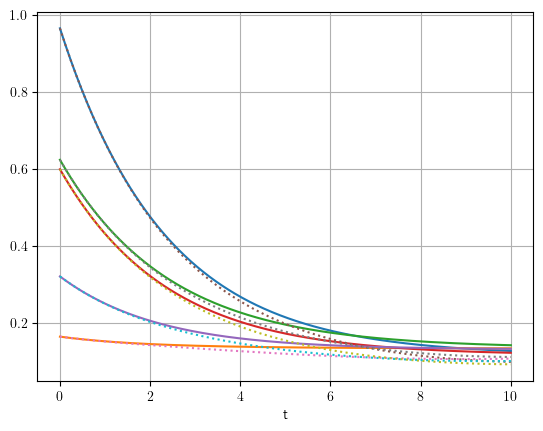

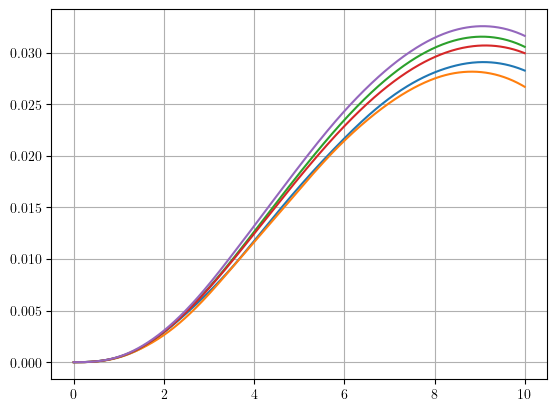

In [11]:
xc_0 = R@x_0
 
def fun(t,x):
    Ft = Fs[1] + t*Fs[2]
    return Ft@x

result = sp.integrate.solve_ivp(fun,[0,(Nt+1)*dt], xc_0, t_eval=ts)

ys_c = []
for j in range(result.y.shape[1]):
   ys_c.append(result.y[:,j].reshape([m,]))

ys_c = np.array(ys_c)

plt.figure()
plt.plot(ts,ys)
plt.plot(ts,ys_c,':')
plt.grid()
plt.xlabel('t')
plt.show()

plt.figure()
plt.plot(ts,ys-ys_c)
plt.grid()
plt.show()

### Comparison of different orders

[0.00466438] [[4.79809976e-09]]
[0.00018194] [[1.18625737e-11]]
[8.9476393e-08] [[1.05002138e-18]]
[3.15686061e-13] [[1.15512969e-28]]
[5.53106569e-17] [[1.26607347e-37]]
[3.08119292e-21] [[5.58040923e-47]]


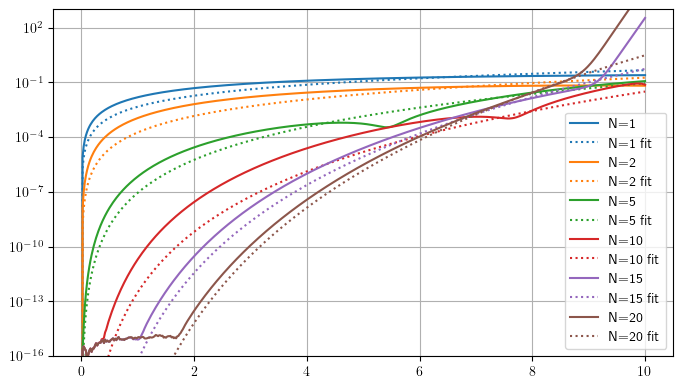

In [12]:
Ns = [1,2,5,10,15,20]

data = [ts]
plt.figure(figsize=(16/2,9/2))
fit = []
for order in Ns:
    Es = get_Es(Fs[:order+1], M_max=100)

    xcm_0 = R@x_0

    es = []
    for E in Es:
        es.append(E@xcm_0)

    ys_mc = []
    for t in ts:
        xcm_t = np.zeros_like(xcm_0)
        for k,e in enumerate(es):
            xcm_t = xcm_t + e*(t**k)
        ys_mc.append(xcm_t)

    ys_mc = np.array(ys_mc)

    error = []
    for j in range(Nt+1):
        error.append(np.linalg.norm(ys[j,:]-ys_mc[j,:]))
    error = np.array(error)

    data.append(error)

    lines = plt.plot(ts,error, '-', label='N='+str(order))

    def func(x, a):
        return a * x**(order+1)

    popt, pcov = curve_fit(func, ts[100:400], error[100:400])
    print(popt, pcov)

    linecolor = lines[0].get_color()
    plt.plot(ts,func(ts,popt),':',label='N='+str(order)+' fit',color=linecolor)
    fit.append(func(ts,popt))


plt.grid()
plt.yscale('log')
plt.ylim([1e-16,1e3])
plt.legend()
plt.show()

header = ['t']+['n'+str(k) for k in Ns] +['f'+str(k) for k in Ns] 
df = pd.DataFrame(np.concatenate((np.array(data),np.array(fit))).T, columns=header)
df.to_csv('../data/errors.csv',index=False)

[0.00466438] [[4.79809976e-09]]
[0.00018194] [[1.18625737e-11]]
[8.9476393e-08] [[1.05002138e-18]]
[3.15686061e-13] [[1.15512969e-28]]
[5.53106569e-17] [[1.26607347e-37]]
[3.08119292e-21] [[5.58040923e-47]]


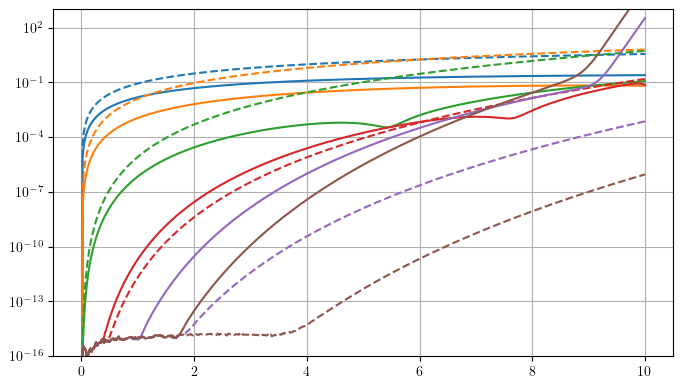

In [25]:
Ns = [1,2,5,10,15,20]

data = [ts]
plt.figure(figsize=(16/2,9/2))
fit = []
for order in Ns:
    Es = get_Es(Fs[:order+1], M_max=100)

    xcm_0 = R@x_0

    es = []
    for E in Es:
        es.append(E@xcm_0)

    ys_mc = []
    for t in ts:
        xcm_t = np.zeros_like(xcm_0)
        for k,e in enumerate(es):
            xcm_t = xcm_t + e*(t**k)
        ys_mc.append(xcm_t)

    ys_mc = np.array(ys_mc)

    error = []
    for j in range(Nt+1):
        error.append(np.linalg.norm(ys[j,:]-ys_mc[j,:]))
    error = np.array(error)

    data.append(error)

    lines = plt.plot(ts,error, '-', label='N='+str(order))

    def func(x, a):
        return a * x**(order+1)

    popt, pcov = curve_fit(func, ts[100:400], error[100:400])
    print(popt, pcov)

    linecolor = lines[0].get_color()
    #plt.plot(ts,func(ts,popt),':',label='N='+str(order)+' fit',color=linecolor)
    #fit.append(func(ts,popt))

    tst = []
    powers = []
    for k in range(order+1):
        powers.append(R@np.linalg.matrix_power(L,k)@J)
    for t in ts:
        tmp = R@x_0
        for k in range(1,order+1):
            tmp = tmp + t**k/math.factorial(k)*powers[k]@R@x_0
        tst.append(tmp)
    tst = np.array(tst)
    error_exp = []
    for j in range(Nt+1):
        error_exp.append(np.linalg.norm(ys[j,:]-tst[j,:]))
    error_exp = np.array(error_exp)
    plt.plot(ts,error_exp,'--',label='N='+str(order)+' exp',color=linecolor)
    fit.append(error_exp)

plt.grid()
plt.yscale('log')
plt.ylim([1e-16,1e3])
#plt.legend()
plt.show()

header = ['t']+['n'+str(k) for k in Ns] +['f'+str(k) for k in Ns] 
df = pd.DataFrame(np.concatenate((np.array(data),np.array(fit))).T, columns=header)
df.to_csv('../data/errors.csv',index=False)